In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## SECTION A: Exploring Missing Data

### Q1. Load the dataset. Display its shape, column names and data types.

In [5]:
data = pd.read_csv("titanic.csv")
#print(data)
print(data.shape)
print(data.columns)
print(data.dtypes)

(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object


### Q2. Find the count and percentage of missing values in each column. List the columns that contain missing values and classify each as numeric or categorical.

In [13]:
missing_count = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_table)

missing_columns = missing_table[missing_table["Missing Count"] > 0]
print(missing_columns)

for col in missing_columns.index:
    if pd.api.types.is_numeric_dtype(data[col]):
        data_type = "Numeric"
    else:
        data_type = "Categorical"

    print(col, "->", data_type)

             Missing Count  Missing Percentage
survived                 0            0.000000
pclass                   0            0.000000
sex                      0            0.000000
age                    177           19.865320
sibsp                    0            0.000000
parch                    0            0.000000
fare                     0            0.000000
embarked                 2            0.224467
class                    0            0.000000
who                      0            0.000000
adult_male               0            0.000000
deck                   688           77.216611
embark_town              2            0.224467
alive                    0            0.000000
alone                    0            0.000000
             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467
age -> Numeri

### Q3. The column deck has about 77% missing values. State whether you would impute or drop it, and justify your decision.

In [14]:
df = data.drop("deck", axis=1)
print(df)

# The deck column should be dropped because it contains approximately 77% missing values.
# Imputing such a large proportion of missing categorical data may introduce inaccurate information and bias.

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male  embark_town alive  alone  


### Q4. Visualize the missing values using a heatmap and write one observation from the plot.

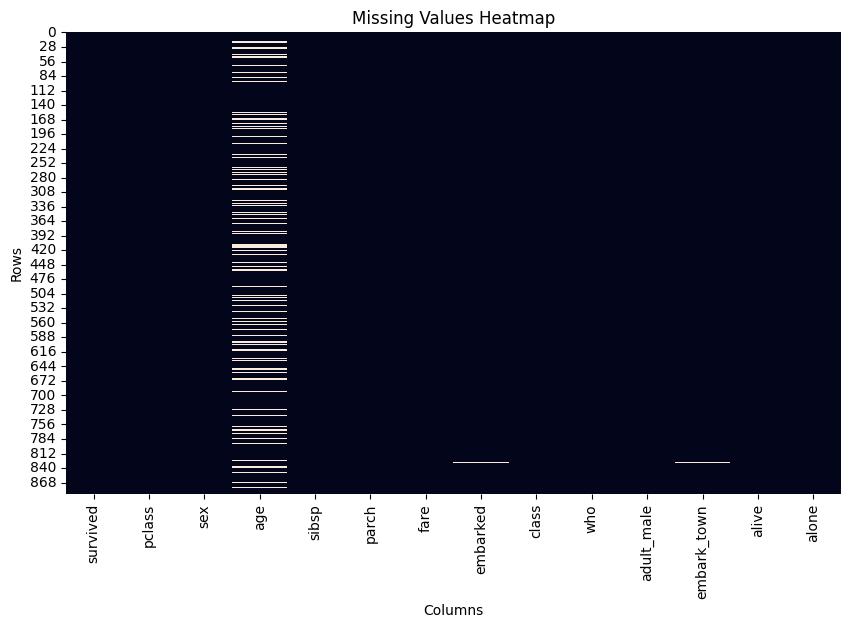

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

## SECTION B: Imputation Techniques

### Q5. Fill the missing values of age using the mean and store the result in a new column age_mean

In [20]:
# Calculate mean of age
age_mean_value = data["age"].mean()

# Create new column
data["age_mean"] = data["age"].fillna(age_mean_value)

print(data[["age", "age_mean"]].head(10))

    age   age_mean
0  22.0  22.000000
1  38.0  38.000000
2  26.0  26.000000
3  35.0  35.000000
4  35.0  35.000000
5   NaN  29.699118
6  54.0  54.000000
7   2.0   2.000000
8  27.0  27.000000
9  14.0  14.000000


### Q6. Fill the missing values of age using the median and store the result in a new column age_median.

In [21]:
# Calculate median
age_median_value = df["age"].median()

# Create new column
df["age_median"] = df["age"].fillna(age_median_value)

print(df[["age", "age_median"]].head(10))

    age  age_median
0  22.0        22.0
1  38.0        38.0
2  26.0        26.0
3  35.0        35.0
4  35.0        35.0
5   NaN        28.0
6  54.0        54.0
7   2.0         2.0
8  27.0        27.0
9  14.0        14.0


### Q7. Plot histograms of the original age, age_mean and age_median. Explain how each imputation changes the distribution.

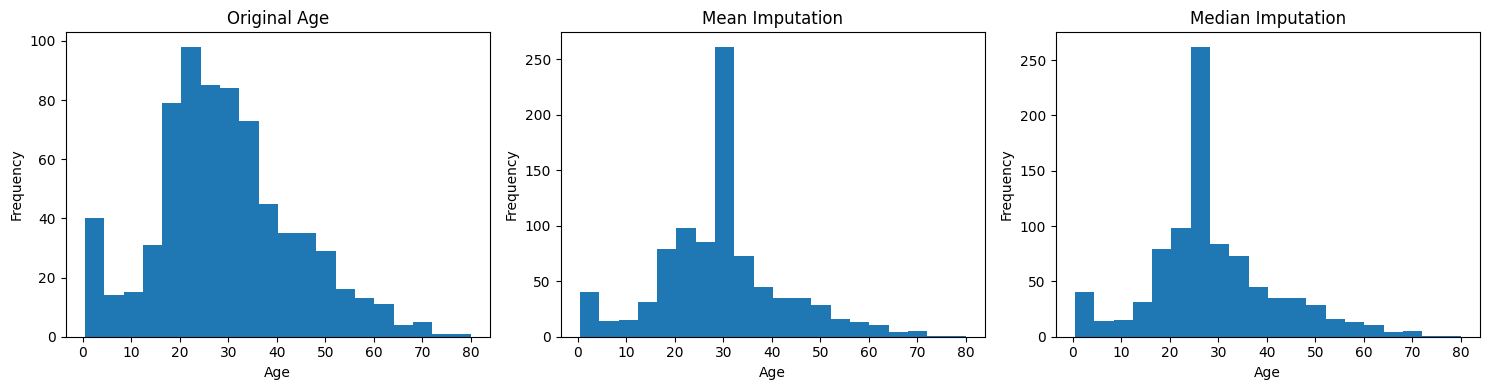

In [24]:
plt.figure(figsize=(15, 4))

# Original age
plt.subplot(1, 3, 1)
plt.hist(data["age"].dropna(), bins=20)
plt.title("Original Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Mean imputation
plt.subplot(1, 3, 2)
plt.hist(data["age_mean"], bins=20)
plt.title("Mean Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Median imputation
plt.subplot(1, 3, 3)
plt.hist(df["age_median"], bins=20)
plt.title("Median Imputation")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Q8. Fill the missing values of embarked using the mode. Verify that no missing values remain in this column.

In [25]:
# Find mode
embarked_mode = df["embarked"].mode()[0]

# Fill missing values
df["embarked"] = df["embarked"].fillna(embarked_mode)

# Verify
print("Missing values in embarked:",
      df["embarked"].isnull().sum())

Missing values in embarked: 0


### Q9. Explain why mean or median cannot be used to impute embarked.
embarked is a categorical column, containing categories such as:
S, C, Q

Mean and median are mathematical operations for numerical values.

Therefore, we use the mode, which is the most frequently occurring category.

### Q10. Compare the standard deviation of age before and after mean imputation. What do you observe and why is it a concern?

In [27]:
original_std = df["age"].std()

mean_imputed_std = data["age_mean"].std()

print("Original age standard deviation:", original_std)
print("After mean imputation:", mean_imputed_std)

print("Difference:", original_std - mean_imputed_std)

Original age standard deviation: 14.526497332334042
After mean imputation: 13.002015226002882
Difference: 1.5244821063311598


### Q11. Impute age using the median age grouped by pclass and sex. Explain whether this is better than a single global median.

In [ ]:
# Calculate median age for each pclass and sex group
group_median = df.groupby(["pclass", "sex"])["age"].transform("median")

# Fill missing age using group median
df["age_group_median"] = df["age"].fillna(group_median)

print(df[["pclass", "sex", "age", "age_group_median"]].head(10))

# Grouped median imputation is generally more informative than a single global median because it considers differences between passenger class and sex. 
# Therefore, the imputed age can better represent the characteristics of each group.

   pclass     sex   age  age_group_median
0       3    male  22.0              22.0
1       1  female  38.0              38.0
2       3  female  26.0              26.0
3       1  female  35.0              35.0
4       3    male  35.0              35.0
5       3    male   NaN              25.0
6       1    male  54.0              54.0
7       3    male   2.0               2.0
8       3  female  27.0              27.0
9       2  female  14.0              14.0


## SECTION C: Encoding Categorical Variables

### Q12. Identify all categorical columns present in the dataset.

In [30]:
categorical_columns = data.select_dtypes(include=["object", "category"]).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='str')


C:\Users\TEJASWINI\AppData\Local\Temp\ipykernel_23324\415485847.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=["object", "category"]).columns


### Q13. Apply label encoding to sex using LabelEncoder. Display the mapping of each category to its numeric code

In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["sex_encoded"] = le.fit_transform(df["sex"])

print(df[["sex", "sex_encoded"]].head())

      sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1


### Q14. Apply one-hot encoding to embarked using pd.get_dummies(). State how many new columns are create

In [32]:
encoded_embarked = pd.get_dummies(
    df["embarked"],
    prefix="embarked"
)

print(encoded_embarked.head())

   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


### Q15. Repeat the one-hot encoding of embarked using OneHotEncoder from scikit-learn and mention one difference from the pandas method.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

embarked_encoded = encoder.fit_transform(df[["embarked"]])

print(embarked_encoded)
print("Categories:", encoder.categories_)

encoded_df = pd.DataFrame(w
    embarked_encoded,
    columns=encoder.get_feature_names_out(["embarked"])
)

print(encoded_df.head())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
Categories: [array(['C', 'Q', 'S'], dtype=object)]
   embarked_C  embarked_Q  embarked_S
0         0.0         0.0         1.0
1         1.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         0.0         0.0         1.0


### Q16. What is the dummy variable trap? Use drop_first=True to avoid it and explain why this works.

In [ ]:
pd.get_dummies(df["embarked"], drop_first=True)
#drop_first=True removes one dummy variable, preventing perfect linear dependence among the dummy variables and avoiding the dummy variable trap.

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


### Q17. Explain why label encoding is unsuitable for embarked (S, C, Q). What wrong assumption could a model make?

Label encoding is unsuitable because S, C, and Q are nominal categories with no natural order. Numerical encoding may incorrectly make the model assume an ordinal relationship.

### Q18. The column class has values First, Second and Third. Apply ordinal encoding using .map() so that the order is preserved, and explain why this is preferable to one-hot encoding here.

In [ ]:
df["class_encoded"] = df["class"].map({
    "First": 1,
    "Second": 2,
    "Third": 3
})

print(df[["class", "class_encoded"]].head())

# Ordinal encoding is preferable because passenger class has a meaningful order: First, Second, Third. 
# One-hot encoding would treat the three classes as completely unrelated categories and lose this ordering information.

   class  class_encoded
0  Third              3
1  First              1
2  Third              3
3  First              1
4  Third              3


## SECTION D: Feature Scaling

### Q19. Display the minimum, maximum, mean and standard deviation of age and fare. State which feature has the larger range.

In [38]:
print(df[["age", "fare"]].agg([
    "min",
    "max",
    "mean",
    "std"
]))

age_range = df["age"].max() - df["age"].min()
fare_range = df["fare"].max() - df["fare"].min()

print("Age range:", age_range)
print("Fare range:", fare_range)

            age        fare
min    0.420000    0.000000
max   80.000000  512.329200
mean  29.699118   32.204208
std   14.526497   49.693429
Age range: 79.58
Fare range: 512.3292


### Q20. Apply standardization (StandardScaler) to age and fare. Verify that the mean is approximately 0 and the standard deviation approximately 1.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    df[["age", "fare"]]
)
print("Mean:")
print(df[["age_scaled", "fare_scaled"]].mean())

Mean:
age_scaled     2.388379e-16
fare_scaled    3.987333e-18
dtype: float64


### Q21. Apply normalization (MinMaxScaler) to age and fare. Verify that all values lie between 0 and 1.

In [41]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df[["age_normalized", "fare_normalized"]] = minmax.fit_transform(
    df[["age", "fare"]]
)

print(df[["age_normalized", "fare_normalized"]].min())
print(df[["age_normalized", "fare_normalized"]].max())

age_normalized     0.0
fare_normalized    0.0
dtype: float64
age_normalized     1.0
fare_normalized    1.0
dtype: float64


### Q22. Plot the distribution of fare before scaling, after standardization and after normalization. State what changes and what remains the same.

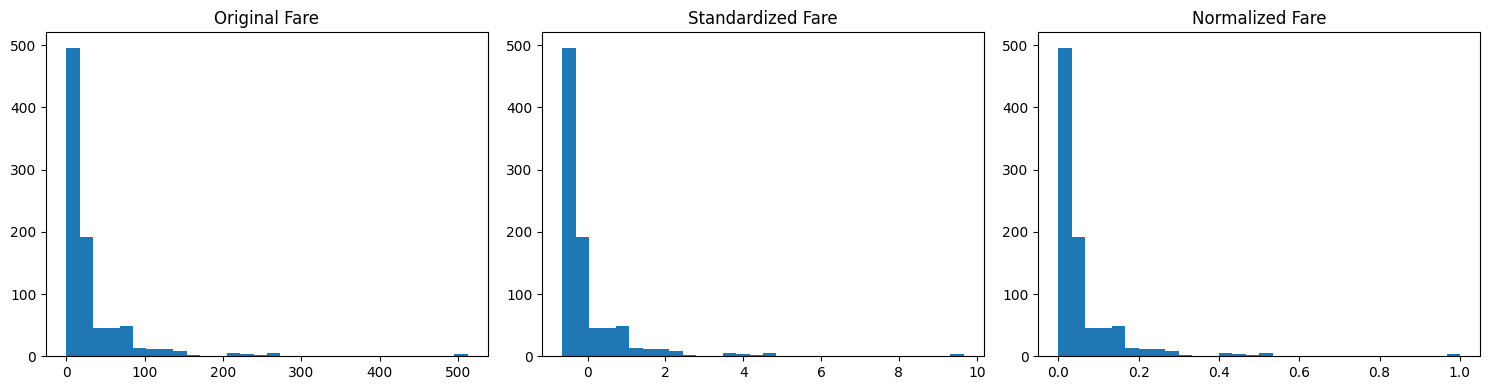

In [ ]:
plt.figure(figsize=(15, 4))

# Original
plt.subplot(1, 3, 1)
plt.hist(df["fare"], bins=30)
plt.title("Original Fare")

# Standardized
plt.subplot(1, 3, 2)
plt.hist(df["fare_scaled"], bins=30)
plt.title("Standardized Fare")

# Normalized
plt.subplot(1, 3, 3)
plt.hist(df["fare_normalized"], bins=30)
plt.title("Normalized Fare")

plt.tight_layout()
plt.show()

#Scaling changes the numerical range of the feature but preserves the relative distribution and ordering of the observations.

### Q23. Write the formulas for standardization and normalization. Compute both manually for the first five values of age and match them with the scikit-learn output.

1. Standardization formula
$$ z = \frac{x-\mu}{\sigma} $$

Where:

x = original value
μ = mean
σ = standard deviation
z = standardized value

2. Normalization formula
$$ x' = \frac{x-x_{min}}{x_{max}-x_{min}} $$

Where:

x = original value
xmin = minimum value
xmax = maximum value
x' = normalized value

In [45]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Remove missing age values
age = df["age"].dropna()

# Mean, standard deviation, minimum and maximum
mean_age = age.mean()
std_age = age.std(ddof=0)
min_age = age.min()
max_age = age.max()

print("Mean:", mean_age)
print("Standard Deviation:", std_age)
print("Minimum:", min_age)
print("Maximum:", max_age)

# First 5 age values
first_five = age.head(5)

# Manual Standardization
manual_standard = (first_five - mean_age) / std_age

# Manual Normalization
manual_normalized = (first_five - min_age) / (max_age - min_age)

print("\nManual Standardization:")
print(manual_standard)

print("\nManual Normalization:")
print(manual_normalized)

Mean: 29.69911764705882
Standard Deviation: 14.516321150817316
Minimum: 0.42
Maximum: 80.0

Manual Standardization:
0   -0.530377
1    0.571831
2   -0.254825
3    0.365167
4    0.365167
Name: age, dtype: float64

Manual Normalization:
0    0.271174
1    0.472229
2    0.321438
3    0.434531
4    0.434531
Name: age, dtype: float64
